# Increasing-size Vertex cover
**Course:** Data Structures & Algorithms 2

In [9]:
#Week1

#All combinations of vertices

def all_combinations(vertices):
    combinations = [[]]
    n = len(vertices)

    for i in range(0, n):
        temp = combinations.copy()

        for j in range(0, len(temp)):
            temp[j] = temp[j] + [vertices[i]]

        combinations.extend(temp)

    return combinations

#Vertex Cover check

def getAllEdges(matrix):
    allEdges = []

    for i in range(0, len(matrix)):
        for j in range(0, len(matrix[0])):
            if matrix[i][j] == 1:
                allEdges.append([i+1]+[j+1])

    return allEdges

def checkCover(matrix, vertices):
    allPairs = getAllEdges(matrix)

    for pair in allPairs[:]:
        if any(vertex in vertices for vertex in pair):
            allPairs.remove(pair)

    if len(allPairs) == 0:
        return True

    return False

#Brute-force Vertex Cover

def findCover(matrix, vertices):
    allCombinations = all_combinations(vertices)
    bestCombination = [0] * 1000

    for combination in allCombinations:
        if checkCover(matrix, combination) and len(combination) < len(bestCombination):
            bestCombination = combination
            
    return bestCombination


#Random graph generator

def getAllPossiblePairs(vertices):
    pairs = []
    
    for vertice in vertices:
        for i in range(0, len(vertices)):
            if vertice != vertices[i]:
                pairs.append([vertice,vertices[i]])

    return pairs

import random

def should_do(p):
    return random.random() <= p

def graphGenerator(vertices, p):
    pairs = getAllPossiblePairs(vertices)
    matrix = [[0] * len(vertices) for _ in range(len(vertices))]

    for pair in pairs:
        if should_do(p):
            matrix[pair[0]-1][pair[1]-1] = 1

    return matrix

#Week2
def allVertexCombinations(n):
    combinations = [[]]

    for i in range(1,n+1):
        temp = [subset for subset in combinations if len(subset) == i - 1]

        for j in range(1,n+1):
            for k in range(0,len(temp)):
                if temp[k] == [] or j > temp[k][-1]:
                    combinations.append(temp[k] + [j])
    
    return combinations


def findCoverByIncreasing(matrix):
    allIncreasingCombinations = allVertexCombinations(len(matrix))

    for combination in allIncreasingCombinations:
        if checkCover(matrix, combination):
            return combination
            
    return []

## Performance test

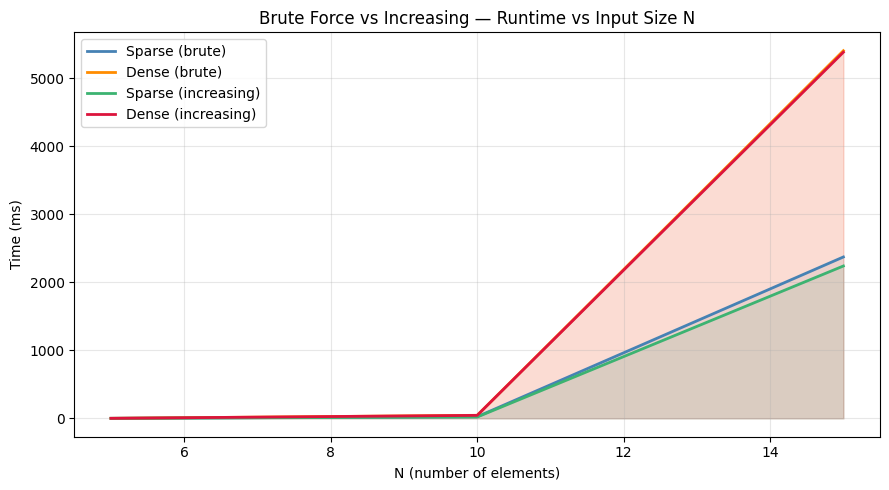

In [10]:
import time
import statistics

import matplotlib.pyplot as plt

sizes = [5,10,15]
sparse_times = []
dense_times = []
sparse_times_brute = []
dense_times_brute = []
repeats = 10


for size in sizes:
    sparse_runs = []
    dense_runs = []
    sparse_runs_brute = []
    dense_runs_brute = []

    for _ in range(repeats):
        vertices = list(range(1, size + 1))

        sparseGraph = graphGenerator(vertices, 0.3)
        denseGraph = graphGenerator(vertices, 0.7)

        start = time.perf_counter()
        findCover(sparseGraph, vertices.copy())
        end = time.perf_counter()
        sparse_runs_brute.append((end - start) * 1000)

        start = time.perf_counter()
        findCoverByIncreasing(sparseGraph)
        end = time.perf_counter()
        sparse_runs.append((end - start) * 1000)

        start = time.perf_counter()
        findCover(denseGraph, vertices.copy())
        end = time.perf_counter()
        dense_runs_brute.append((end - start) * 1000)

        start = time.perf_counter()
        findCoverByIncreasing(denseGraph)
        end = time.perf_counter()
        dense_runs.append((end - start) * 1000)

    sparse_times_brute.append(statistics.mean(sparse_runs_brute))
    dense_times_brute.append(statistics.mean(dense_runs_brute))
    sparse_times.append(statistics.mean(sparse_runs))
    dense_times.append(statistics.mean(dense_runs))

plt.figure(figsize=(9, 5))
plt.plot(sizes, sparse_times_brute, label='Sparse (brute)', color='steelblue', linewidth=2)
plt.plot(sizes, dense_times_brute, label='Dense (brute)', color='darkorange', linewidth=2)
plt.fill_between(sizes, sparse_times_brute, alpha=0.10, color='steelblue')
plt.fill_between(sizes, dense_times_brute, alpha=0.10, color='darkorange')
plt.plot(sizes, sparse_times, label='Sparse (increasing)', color='mediumseagreen', linewidth=2)
plt.plot(sizes, dense_times, label='Dense (increasing)', color='crimson', linewidth=2)
plt.fill_between(sizes, sparse_times, alpha=0.10, color='mediumseagreen')
plt.fill_between(sizes, dense_times, alpha=0.10, color='crimson')
plt.xlabel('N (number of elements)')
plt.ylabel('Time (ms)')
plt.title('Brute Force vs Increasing — Runtime vs Input Size N')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_plot.png', dpi=150)
plt.legend()
plt.show()
